wavelength   n(lambda)   exit angle(deg)   deviation(deg)
0.40         1.5250        1.312            11.312
0.45         1.5198        1.203            11.203
0.50         1.5160        1.126            11.126
0.55         1.5132        1.068            11.068
0.58         1.5119        1.040            11.040
0.62         1.5104        1.009            11.009
0.70         1.5082        0.963            10.963


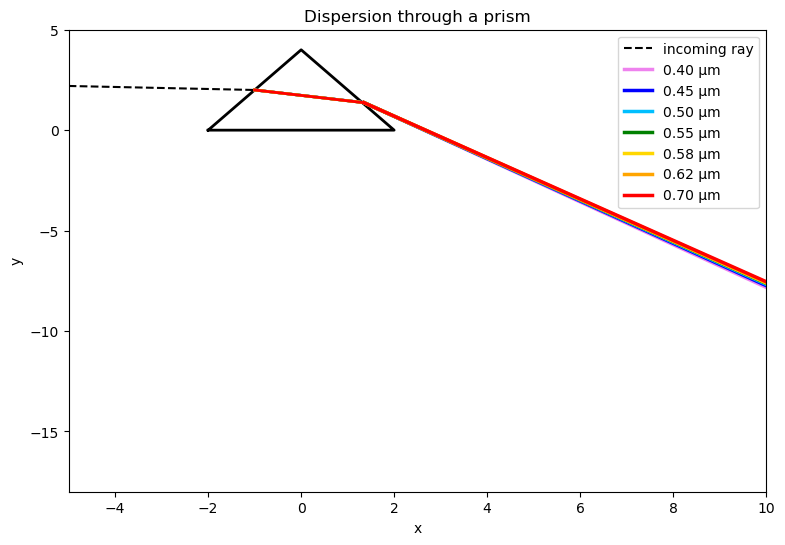

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# n(lambda)
wavelengths = np.array([0.4, 0.45, 0.5, 0.55, 0.58, 0.62, 0.7])
n_air = 1
n_prism = 1.50 + 0.004 / wavelengths**2

# angles
theta0_deg = 30
prism_angle_deg = 20

theta0 = np.deg2rad(theta0_deg)
prism_angle = np.deg2rad(prism_angle_deg)

# prism formulas
theta = np.arcsin((n_air / n_prism) * np.sin(theta0))  
prism_thetas = prism_angle - theta                      
exit_thetas = np.arcsin((n_prism / n_air) * np.sin(prism_thetas))
deviation = theta0 + exit_thetas - prism_angle

print("wavelength   n(lambda)   exit angle(deg)   deviation(deg)")
for lam, n_val, ex, dev in zip(wavelengths, n_prism, np.degrees(exit_thetas), np.degrees(deviation)):
    print(f"{lam:.2f}         {n_val:.4f}        {ex:.3f}            {dev:.3f}")

colors = ['violet', 'blue', 'deepskyblue', 'green', 'gold', 'orange', 'red']

plt.figure(figsize=(9, 6))

# prism
prism_x = [-2, 0, 2, -2]
prism_y = [0, 4, 0, 0]
plt.plot(prism_x, prism_y, 'k-', lw=2)

# incoming ray
x_in = [-5, -1]
y_in = [2.2, 2.0]
plt.plot(x_in, y_in, 'k--', lw=1.5, label='incoming ray')

# exaggerate the spread of each wavelength to make them easier to see in the model
spread_scale = 5

for i in range(len(wavelengths)):
    # inside prism
    x1 = [-1, 1.35]
    y1 = [2.0, 2.0 - np.tan(theta[i]) * 1.8]
    plt.plot(x1, y1, color=colors[i], lw=2)

    # outgoing ray
    x2 = [1.35, 10]
    y2 = [y1[-1], y1[-1] - spread_scale * np.tan(deviation[i]) * (10 - 0.8)]
    plt.plot(x2, y2, color=colors[i], lw=2.5, label=f"{wavelengths[i]:.2f} μm")

plt.xlim(-5, 10)
plt.ylim(-18, 5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dispersion through a prism")
plt.legend()
plt.show()

Model Verification

To verify the model, I've checked the deviation in degrees for the cyan and violet wavelengths by hand to see if it matches the output values given by the code above. Using the prism formulas for r2, A, r1, n_prism, n_air, and that deviation is equal to the incident angle plus the exit angle plus the prism angle, I match the deviations of 11.31 and 11.13 for the .4 and .5 um wavelengths respectively.

AI Usage

AI assisted with coding the prism and instructed how to plot multiple different rays of different wavelengths into a cohesive plot. It also artificially increased the deviation between each wavelength to better see the different colors. 